## Keyword searches with lemmatization

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/inqsoncharoen/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/inqsoncharoen/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Year
2004    0
2008    1
2012    0
2016    0
2020    0
2024    1
Name: Word_Count, dtype: int64


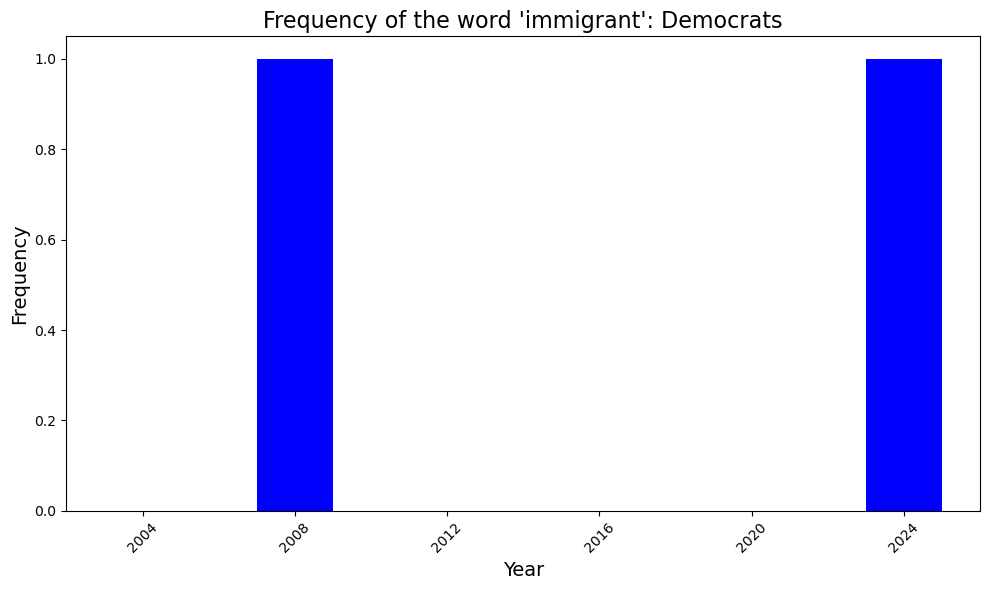

Saved: /Users/inqsoncharoen/Documents/Election_Analysis/immigrant_freq_dems.csv


In [67]:
import pandas as pd
import matplotlib.pyplot as plt
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk
nltk.download("punkt")
nltk.download("wordnet")

#i will come up with more efficient and elegant code. But for what it"s worth w/ pres deadlines, i"m running two cells

file_path = "/Users/inqsoncharoen/Documents/Election_Analysis/combined_dems.csv"
data = pd.read_csv(file_path)

search_word = "immigrant"

lemmatizer = WordNetLemmatizer() #initialize lem.

def count_word_frequency(word, data): #func to count freq in all forms
    word = word.lower()  #just in case for my paranoid ass
    lemmatized_word = lemmatizer.lemmatize(word)

    def count_occurrences(text):
        tokens = word_tokenize(text.lower())
        lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
        return lemmatized_tokens.count(lemmatized_word)

    data["Word_Count"] = data["Ads_Merged"].apply(count_occurrences)
    yearly_counts = data.groupby("Year")["Word_Count"].sum()
    return yearly_counts

def plot_word_frequency(word, yearly_counts):
    plt.figure(figsize=(10, 6))
    yearly_counts.plot(kind="bar", color="blue")
    plt.title(f"Frequency of the word '{word}': Democrats", fontsize=16)
    plt.xlabel("Year", fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# if __name__ == "__main__":
#     search_word = "job"
#     yearly_word_counts = count_word_frequency(search_word, data)
#     print(yearly_word_counts)
#     plot_word_frequency(search_word, yearly_word_counts)

def export_to_csv(word, yearly_counts):
    output_file = f"/Users/inqsoncharoen/Documents/Election_Analysis/{word}_freq_dems.csv"
    yearly_counts.to_csv(output_file, index=True, header=["Frequency"])
    print(f"Saved: {output_file}")

if __name__ == "__main__":
    #search_word = "immigrant"
    yearly_word_counts = count_word_frequency(search_word, data)
    print(yearly_word_counts)
    plot_word_frequency(search_word, yearly_word_counts)
    export_to_csv(search_word, yearly_word_counts) #save as csv

Year
2004    0
2008    0
2012    1
2016    0
2020    5
2024    3
Name: Word_Count, dtype: int64


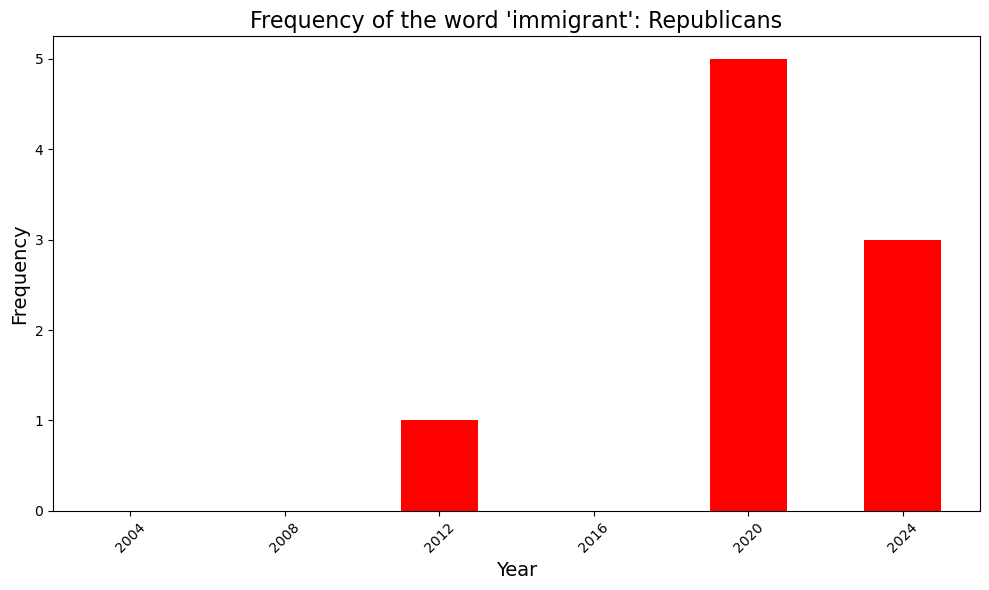

Saved: /Users/inqsoncharoen/Documents/Election_Analysis/immigrant_freq_rep.csv


In [68]:
file_path = "/Users/inqsoncharoen/Documents/Election_Analysis/combined_repub.csv"
data = pd.read_csv(file_path)

lemmatizer = WordNetLemmatizer() #initialize lem.

def count_word_frequency(word, data): #func to count freq in all forms
    word = word.lower()  #just in case for my paranoid ass
    lemmatized_word = lemmatizer.lemmatize(word)

    def count_occurrences(text):
        tokens = word_tokenize(text.lower())
        lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
        return lemmatized_tokens.count(lemmatized_word)

    data["Word_Count"] = data["Ads_Merged"].apply(count_occurrences)
    yearly_counts = data.groupby("Year")["Word_Count"].sum()
    return yearly_counts

def plot_word_frequency(word, yearly_counts):
    plt.figure(figsize=(10, 6))
    yearly_counts.plot(kind="bar", color="red")
    plt.title(f"Frequency of the word '{search_word}': Republicans", fontsize=16)
    plt.xlabel("Year", fontsize=14)
    plt.ylabel("Frequency", fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def export_to_csv_rep(word, yearly_counts):
    output_file = f"/Users/inqsoncharoen/Documents/Election_Analysis/{word}_freq_rep.csv"
    yearly_counts.to_csv(output_file, index=True, header=["Frequency"])
    print(f"Saved: {output_file}")

if __name__ == "__main__":
    #search_word = "immigrant"
    yearly_word_counts = count_word_frequency(search_word, data)
    print(yearly_word_counts)
    plot_word_frequency(search_word, yearly_word_counts)
    export_to_csv_rep(search_word, yearly_word_counts) #save as csv